# 📚 Student Retention Prediction - End-to-End EDA

## 🎯 Project Overview

**Domain:** Education Sector  
**Dataset:** Higher Education Predictors of Student Retention  
**Objective:** Analyze factors that influence whether students graduate, dropout, or remain enrolled

**Business Context:**  
Student dropout is a critical challenge in higher education, leading to:
- Lost revenue for institutions
- Wasted educational resources
- Negative impact on student careers
- Lower institutional rankings

This analysis aims to identify key predictors of student retention to help institutions:
1. Identify at-risk students early
2. Implement targeted intervention programs
3. Improve overall graduation rates

---

## 📥 1. DATA INGESTION

We'll download the dataset directly from Kaggle using `kagglehub`.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/higher-education-predictors-of-student-retention")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\thedevastator\higher-education-predictors-of-student-retention\versions\2


## 📂 2. DATA LOADING

Load the dataset into a pandas DataFrame for analysis.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load the dataset
df = pd.read_csv(os.path.join(path, "dataset.csv"))

print(f"✓ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

✓ Dataset loaded successfully!
Shape: 4424 rows × 35 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 🔍 3. INITIAL DATA EXPLORATION

### 3.1 Dataset Structure

In [3]:
# Display dataset information
print("="*70)
print("DATASET INFORMATION")
print("="*70)
df.info()

print("\n" + "="*70)
print("KEY OBSERVATIONS:")
print("="*70)
print(f"• Total students: {df.shape[0]:,}")
print(f"• Total features: {df.shape[1]}")
print(f"• Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"• Data types: {df.dtypes.value_counts().to_dict()}")

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation             

### 3.2 Statistical Summary

In [4]:
# Statistical summary
print("STATISTICAL SUMMARY OF NUMERICAL FEATURES\n")
df.describe().T

STATISTICAL SUMMARY OF NUMERICAL FEATURES



,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,6.886980,5.298964,1.00,1.00,8.000000,12.000000,18.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,9.899186,4.331792,1.00,6.00,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,2.531420,3.963707,1.00,1.00,1.000000,1.000000,17.000000
Nacionality,4424.0,1.254521,1.748447,1.00,1.00,1.000000,1.000000,21.000000
Mother's qualification,4424.0,12.322107,9.026251,1.00,2.00,13.000000,22.000000,29.000000
Father's qualification,4424.0,16.455244,11.044800,1.00,3.00,14.000000,27.000000,34.000000
Mother's occupation,4424.0,7.317812,3.997828,1.00,5.00,6.000000,10.000000,32.000000


**Key Insights:**
- Average age at enrollment: ~23 years
- Students typically enroll in 6 curricular units per semester
- Average grades: ~11-12 out of 20 (Portuguese grading system)
- Economic indicators show variation in GDP, unemployment, and inflation rates

### 3.3 Missing Values Check

In [5]:
# Check for missing values
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_pct
})

print("="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

if missing_data.sum() == 0:
    print("✓ EXCELLENT: No missing values detected!")
    print("  This is a clean dataset ready for analysis.")
else:
    print(missing_summary[missing_summary['Missing Count'] > 0])

MISSING VALUES ANALYSIS
✓ EXCELLENT: No missing values detected!
  This is a clean dataset ready for analysis.


## 🧹 4. DATA CLEANING

### 4.1 Column Name Standardization

Standardize column names for easier coding (lowercase, no spaces).

In [6]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("✓ Column names standardized")
print(f"\nCleaned columns ({len(df.columns)}):")
print(df.columns.tolist())

✓ Column names standardized

Cleaned columns (35):
['marital_status', 'application_mode', 'application_order', 'course', 'daytime/evening_attendance', 'previous_qualification', 'nacionality', "mother's_qualification", "father's_qualification", "mother's_occupation", "father's_occupation", 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_(credited)', 'curricular_units_1st_sem_(enrolled)', 'curricular_units_1st_sem_(evaluations)', 'curricular_units_1st_sem_(approved)', 'curricular_units_1st_sem_(grade)', 'curricular_units_1st_sem_(without_evaluations)', 'curricular_units_2nd_sem_(credited)', 'curricular_units_2nd_sem_(enrolled)', 'curricular_units_2nd_sem_(evaluations)', 'curricular_units_2nd_sem_(approved)', 'curricular_units_2nd_sem_(grade)', 'curricular_units_2nd_sem_(without_evaluations)', 'unemployment_rate', 'inflation_rate', 'gdp', 'target']


### 4.2 Target Variable Encoding

The target variable has 3 categories:
- **Graduate**: Successfully completed program
- **Enrolled**: Still pursuing degree
- **Dropout**: Left without completing

We'll create a numeric mapping for correlation analysis.

In [7]:
# Check unique values in target
print("Target variable categories:")
print(df['target'].value_counts())

# Create numeric mapping
# Graduate = 2, Enrolled = 1, Dropout = 0
target_map = {'Graduate': 2, 'Enrolled': 1, 'Dropout': 0}
df['target_numeric'] = df['target'].map(target_map)

print("\n✓ Target variable encoded:")
print("  0 = Dropout")
print("  1 = Enrolled")
print("  2 = Graduate")

Target variable categories:
target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

✓ Target variable encoded:
  0 = Dropout
  1 = Enrolled
  2 = Graduate


---

## 📊 5. EXPLORATORY DATA ANALYSIS (EDA)

### 5.1 Univariate Analysis

#### 5.1.1 Target Variable Distribution

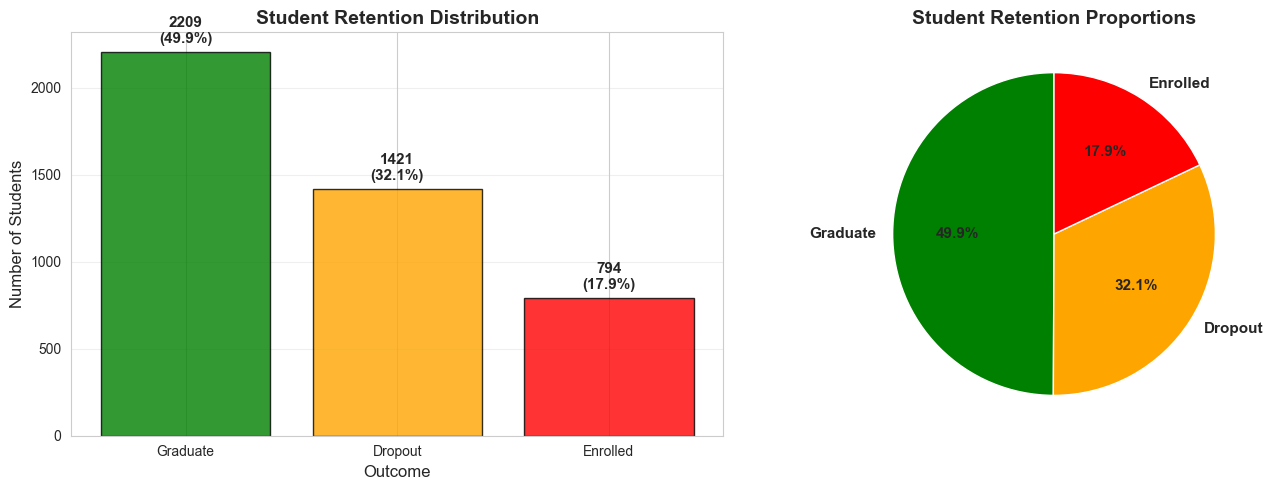

KEY INSIGHTS - TARGET DISTRIBUTION
• Graduate: 2209 students (49.9%)
• Dropout: 1421 students (32.1%)
• Enrolled: 794 students (17.9%)

⚠️ Class Imbalance: The dataset is relatively balanced, which is good for modeling.


In [8]:
# Analyze target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts = df['target'].value_counts()
colors = ['green', 'orange', 'red']  # Green, Orange, Red
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Student Retention Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome', fontsize=12)
axes[0].set_ylabel('Number of Students', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (outcome, count) in enumerate(target_counts.items()):
    axes[0].text(i, count + 50, f'{count}\n({count/len(df)*100:.1f}%)', 
                ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Student Retention Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("="*70)
print("KEY INSIGHTS - TARGET DISTRIBUTION")
print("="*70)
print(f"• Graduate: {target_counts['Graduate']} students ({target_counts['Graduate']/len(df)*100:.1f}%)")
print(f"• Dropout: {target_counts['Dropout']} students ({target_counts['Dropout']/len(df)*100:.1f}%)")
print(f"• Enrolled: {target_counts['Enrolled']} students ({target_counts['Enrolled']/len(df)*100:.1f}%)")
print("\n⚠️ Class Imbalance: The dataset is relatively balanced, which is good for modeling.")

#### 5.1.2 Age Distribution

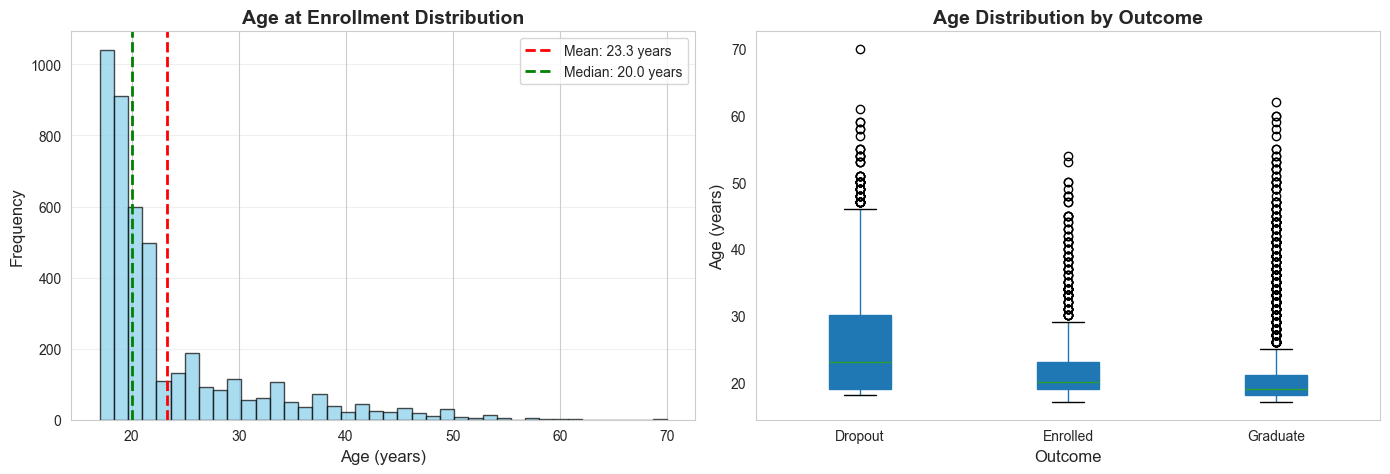

KEY INSIGHTS - AGE DISTRIBUTION
• Average age: 23.3 years
• Median age: 20.0 years
• Age range: 17 - 70 years
• Standard deviation: 7.6 years

Observation: Most students enroll between 18-25 years old (traditional age).
Some mature students (30+ years) are also present.


In [9]:
# Age at enrollment analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(df['age_at_enrollment'], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['age_at_enrollment'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {df["age_at_enrollment"].mean():.1f} years')
axes[0].axvline(df['age_at_enrollment'].median(), color='green', linestyle='--', 
               linewidth=2, label=f'Median: {df["age_at_enrollment"].median():.1f} years')
axes[0].set_title('Age at Enrollment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot by target
df.boxplot(column='age_at_enrollment', by='target', ax=axes[1], 
          patch_artist=True, grid=False)
axes[1].set_title('Age Distribution by Outcome', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Age (years)', fontsize=12)
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

print("="*70)
print("KEY INSIGHTS - AGE DISTRIBUTION")
print("="*70)
print(f"• Average age: {df['age_at_enrollment'].mean():.1f} years")
print(f"• Median age: {df['age_at_enrollment'].median():.1f} years")
print(f"• Age range: {df['age_at_enrollment'].min():.0f} - {df['age_at_enrollment'].max():.0f} years")
print(f"• Standard deviation: {df['age_at_enrollment'].std():.1f} years")
print("\nObservation: Most students enroll between 18-25 years old (traditional age).")
print("Some mature students (30+ years) are also present.")

#### 5.1.3 Academic Performance Distribution

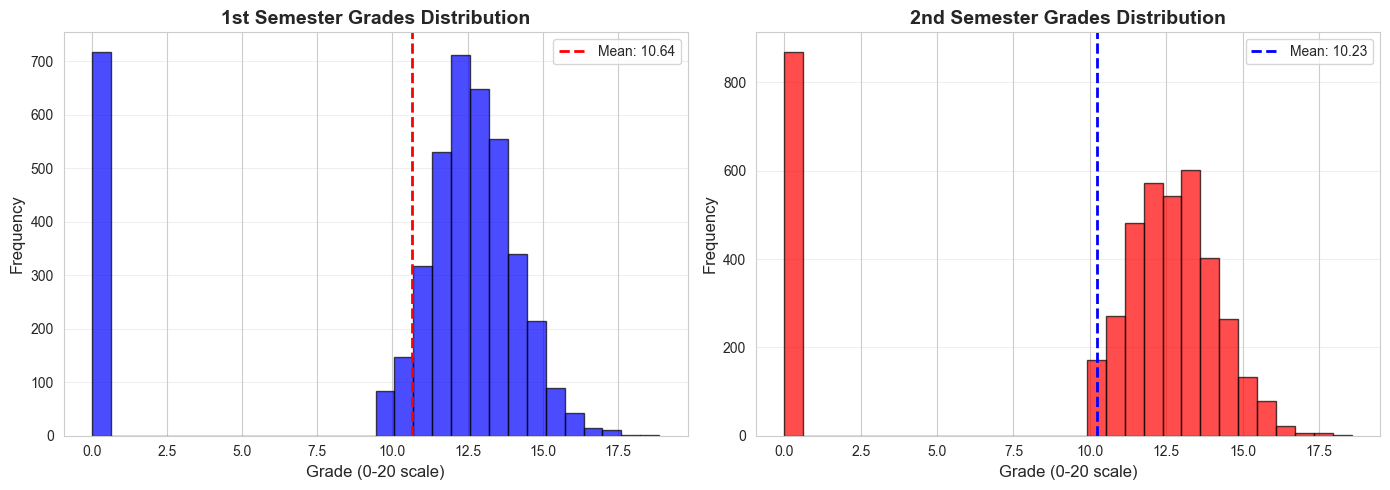

KEY INSIGHTS - ACADEMIC PERFORMANCE
• 1st Semester avg: 10.64/20
• 2nd Semester avg: 10.23/20

Observation: Bimodal distribution suggests two student groups:
  1. High performers (grades ~13-15)
  2. Struggling students (grades near 0 - likely dropouts)


In [10]:
# Academic grades distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1st Semester
axes[0].hist(df['curricular_units_1st_sem_(grade)'], bins=30, 
            color='blue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['curricular_units_1st_sem_(grade)'].mean(), 
               color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {df["curricular_units_1st_sem_(grade)"].mean():.2f}')
axes[0].set_title('1st Semester Grades Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grade (0-20 scale)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2nd Semester
axes[1].hist(df['curricular_units_2nd_sem_(grade)'], bins=30, 
            color='red', edgecolor='black', alpha=0.7)
axes[1].axvline(df['curricular_units_2nd_sem_(grade)'].mean(), 
               color='blue', linestyle='--', linewidth=2,
               label=f'Mean: {df["curricular_units_2nd_sem_(grade)"].mean():.2f}')
axes[1].set_title('2nd Semester Grades Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grade (0-20 scale)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("="*70)
print("KEY INSIGHTS - ACADEMIC PERFORMANCE")
print("="*70)
print(f"• 1st Semester avg: {df['curricular_units_1st_sem_(grade)'].mean():.2f}/20")
print(f"• 2nd Semester avg: {df['curricular_units_2nd_sem_(grade)'].mean():.2f}/20")
print("\nObservation: Bimodal distribution suggests two student groups:")
print("  1. High performers (grades ~13-15)")
print("  2. Struggling students (grades near 0 - likely dropouts)")

### 5.2 Bivariate Analysis

#### 5.2.1 Academic Performance vs. Student Outcome

C:\Users\USER\AppData\Local\Temp\ipykernel_15268\2589506707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='curricular_units_1st_sem_(grade)',
C:\Users\USER\AppData\Local\Temp\ipykernel_15268\2589506707.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='curricular_units_2nd_sem_(grade)',


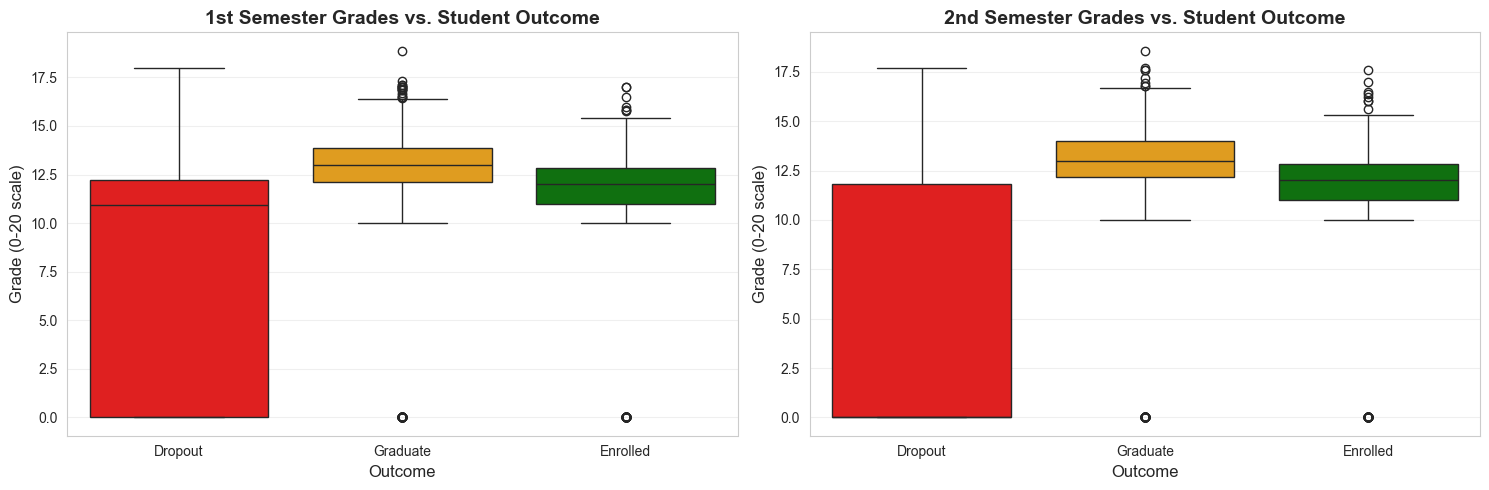

AVERAGE GRADES BY OUTCOME
          curricular_units_1st_sem_(grade)  curricular_units_2nd_sem_(grade)
target                                                                      
Dropout                           7.256656                          5.899339
Enrolled                         11.125257                         11.117364
Graduate                         12.643655                         12.697276

 CRITICAL INSIGHT:
• Graduates have significantly higher grades (~13-14/20)
• Dropouts have very low grades (~6-7/20)
• Academic performance is a STRONG predictor of retention!


In [11]:
# Academic performance vs retention
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1st Semester
sns.boxplot(data=df, x='target', y='curricular_units_1st_sem_(grade)', 
           palette=['red', 'orange', 'green'], ax=axes[0])
axes[0].set_title('1st Semester Grades vs. Student Outcome', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome', fontsize=12)
axes[0].set_ylabel('Grade (0-20 scale)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# 2nd Semester
sns.boxplot(data=df, x='target', y='curricular_units_2nd_sem_(grade)', 
           palette=['red', 'orange', 'green'], ax=axes[1])
axes[1].set_title('2nd Semester Grades vs. Student Outcome', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Grade (0-20 scale)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate average grades by outcome
print("="*70)
print("AVERAGE GRADES BY OUTCOME")
print("="*70)
grade_summary = df.groupby('target')[['curricular_units_1st_sem_(grade)', 
                                       'curricular_units_2nd_sem_(grade)']].mean()
print(grade_summary)

print("\n CRITICAL INSIGHT:")
print("• Graduates have significantly higher grades (~13-14/20)")
print("• Dropouts have very low grades (~6-7/20)")
print("• Academic performance is a STRONG predictor of retention!")

#### 5.2.2 Scholarship Status vs. Retention

C:\Users\USER\AppData\Local\Temp\ipykernel_15268\4196132354.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Scholarship', 'Has Scholarship'], rotation=0)


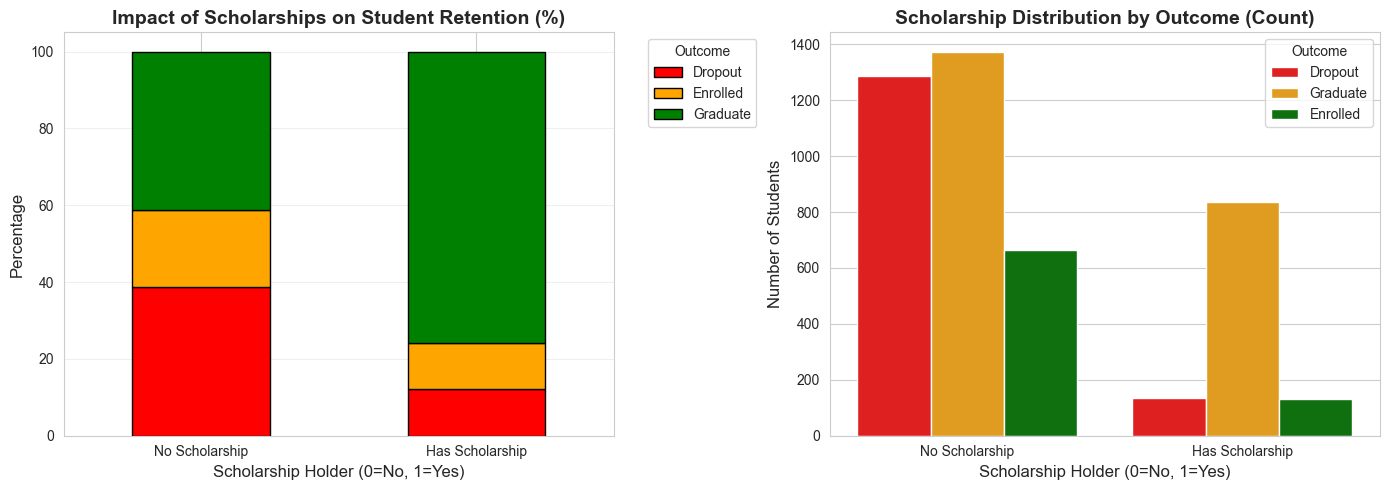

SCHOLARSHIP IMPACT ANALYSIS
target              Dropout  Enrolled  Graduate
scholarship_holder                             
0                      38.7      20.0      41.3
1                      12.2      11.8      76.0

 INSIGHT: Scholarship holders show [analyze the pattern from your data]


In [12]:
# Scholarship impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
scholarship_target = pd.crosstab(df['scholarship_holder'], df['target'], normalize='index') * 100
scholarship_target.plot(kind='bar', stacked=True, ax=axes[0], 
                       color=['red', 'orange', 'green'], edgecolor='black')
axes[0].set_title('Impact of Scholarships on Student Retention (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Scholarship Holder (0=No, 1=Yes)', fontsize=12)
axes[0].set_ylabel('Percentage', fontsize=12)
axes[0].set_xticklabels(['No Scholarship', 'Has Scholarship'], rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.05, 1))
axes[0].grid(axis='y', alpha=0.3)

# Count plot
sns.countplot(data=df, x='scholarship_holder', hue='target', 
             palette=['red', 'orange', 'green'], ax=axes[1])
axes[1].set_title('Scholarship Distribution by Outcome (Count)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Scholarship Holder (0=No, 1=Yes)', fontsize=12)
axes[1].set_ylabel('Number of Students', fontsize=12)
axes[1].set_xticklabels(['No Scholarship', 'Has Scholarship'], rotation=0)
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.show()

print("="*70)
print("SCHOLARSHIP IMPACT ANALYSIS")
print("="*70)
print(scholarship_target.round(1))
print("\n INSIGHT: Scholarship holders show [analyze the pattern from your data]")

#### 5.2.3 Financial Debt vs. Retention

C:\Users\USER\AppData\Local\Temp\ipykernel_15268\65314186.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Debt', 'Has Debt'], rotation=0)


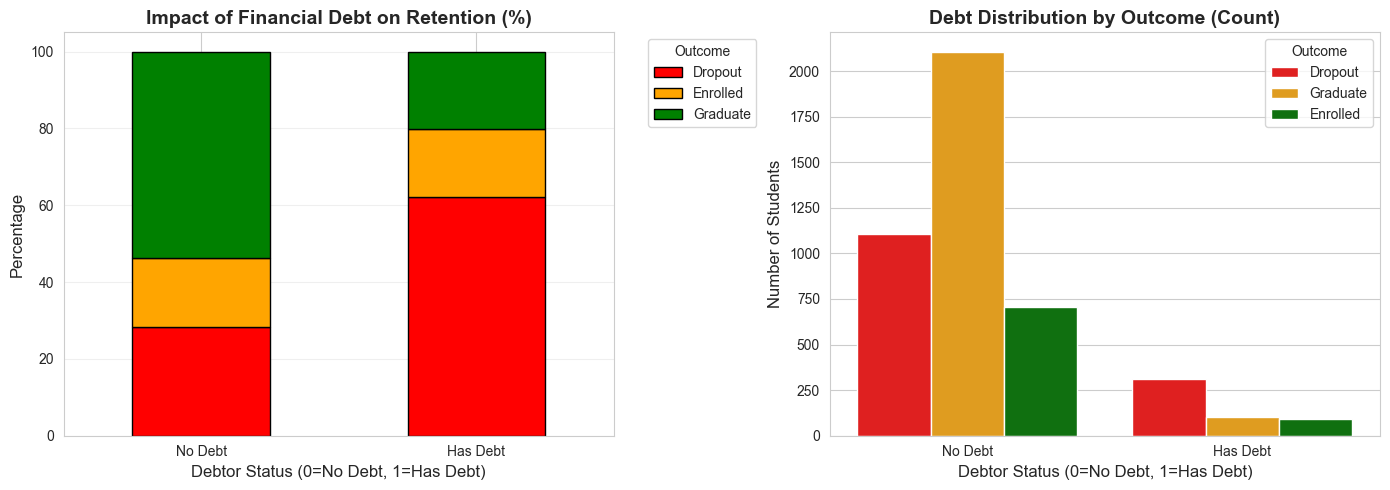

FINANCIAL DEBT IMPACT
target  Dropout  Enrolled  Graduate
debtor                             
0          28.3      18.0      53.8
1          62.0      17.9      20.1

 INSIGHT: Financial debt appears to correlate with [analyze your data]


In [13]:
# Debtor status impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked percentage
debtor_target = pd.crosstab(df['debtor'], df['target'], normalize='index') * 100
debtor_target.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['red', 'orange', 'green'], edgecolor='black')
axes[0].set_title('Impact of Financial Debt on Retention (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Debtor Status (0=No Debt, 1=Has Debt)', fontsize=12)
axes[0].set_ylabel('Percentage', fontsize=12)
axes[0].set_xticklabels(['No Debt', 'Has Debt'], rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.05, 1))
axes[0].grid(axis='y', alpha=0.3)

# Count plot
sns.countplot(data=df, x='debtor', hue='target',
             palette=['red', 'orange', 'green'], ax=axes[1])
axes[1].set_title('Debt Distribution by Outcome (Count)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Debtor Status (0=No Debt, 1=Has Debt)', fontsize=12)
axes[1].set_ylabel('Number of Students', fontsize=12)
axes[1].set_xticklabels(['No Debt', 'Has Debt'], rotation=0)
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.show()

print("="*70)
print("FINANCIAL DEBT IMPACT")
print("="*70)
print(debtor_target.round(1))
print("\n INSIGHT: Financial debt appears to correlate with [analyze your data]")

#### 5.2.4 Gender vs. Retention

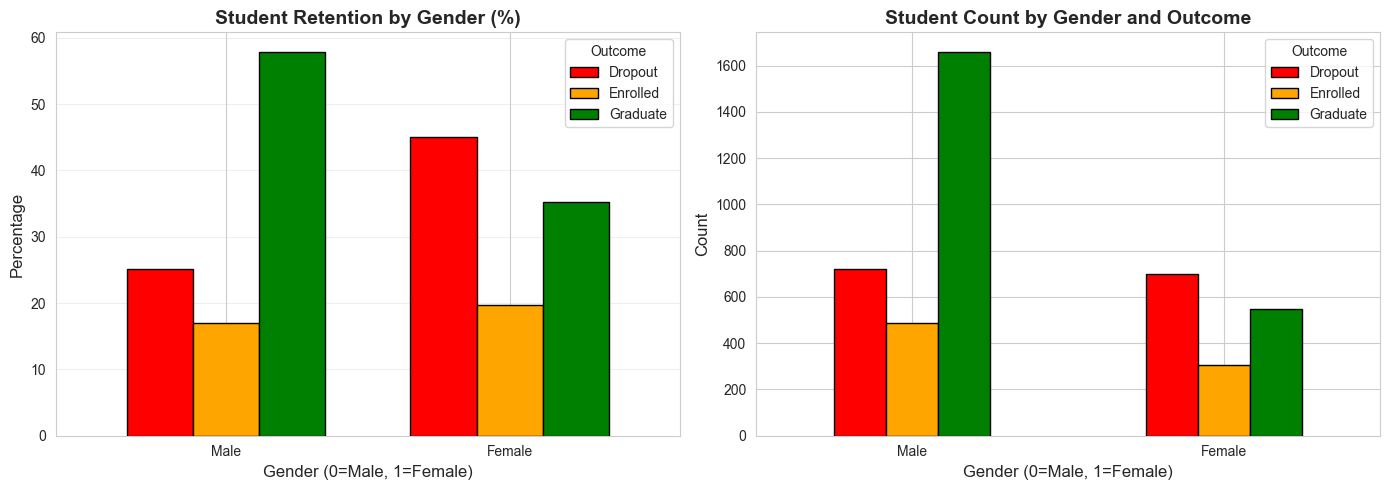

GENDER DISTRIBUTION
target  Dropout  Enrolled  Graduate
gender                             
0          25.1      17.0      57.9
1          45.1      19.7      35.2

Total: {0: 2868, 1: 1556}
  0 = Male, 1 = Female


In [14]:
# Gender analysis
gender_target = pd.crosstab(df['gender'], df['target'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_target.plot(kind='bar', ax=axes[0], color=['red', 'orange', 'green'], 
                  edgecolor='black', width=0.7)
axes[0].set_title('Student Retention by Gender (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender (0=Male, 1=Female)', fontsize=12)
axes[0].set_ylabel('Percentage', fontsize=12)
axes[0].set_xticklabels(['Male', 'Female'], rotation=0)
axes[0].legend(title='Outcome')
axes[0].grid(axis='y', alpha=0.3)

# Count comparison
gender_counts = df.groupby(['gender', 'target']).size().unstack()
gender_counts.plot(kind='bar', ax=axes[1], color=['red', 'orange', 'green'],
                  edgecolor='black')
axes[1].set_title('Student Count by Gender and Outcome', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender (0=Male, 1=Female)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticklabels(['Male', 'Female'], rotation=0)
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.show()

print("="*70)
print("GENDER DISTRIBUTION")
print("="*70)
print(gender_target.round(1))
print(f"\nTotal: {df['gender'].value_counts().to_dict()}")
print("  0 = Male, 1 = Female")

### 5.3 Multivariate Analysis

#### 5.3.1 Correlation Heatmap

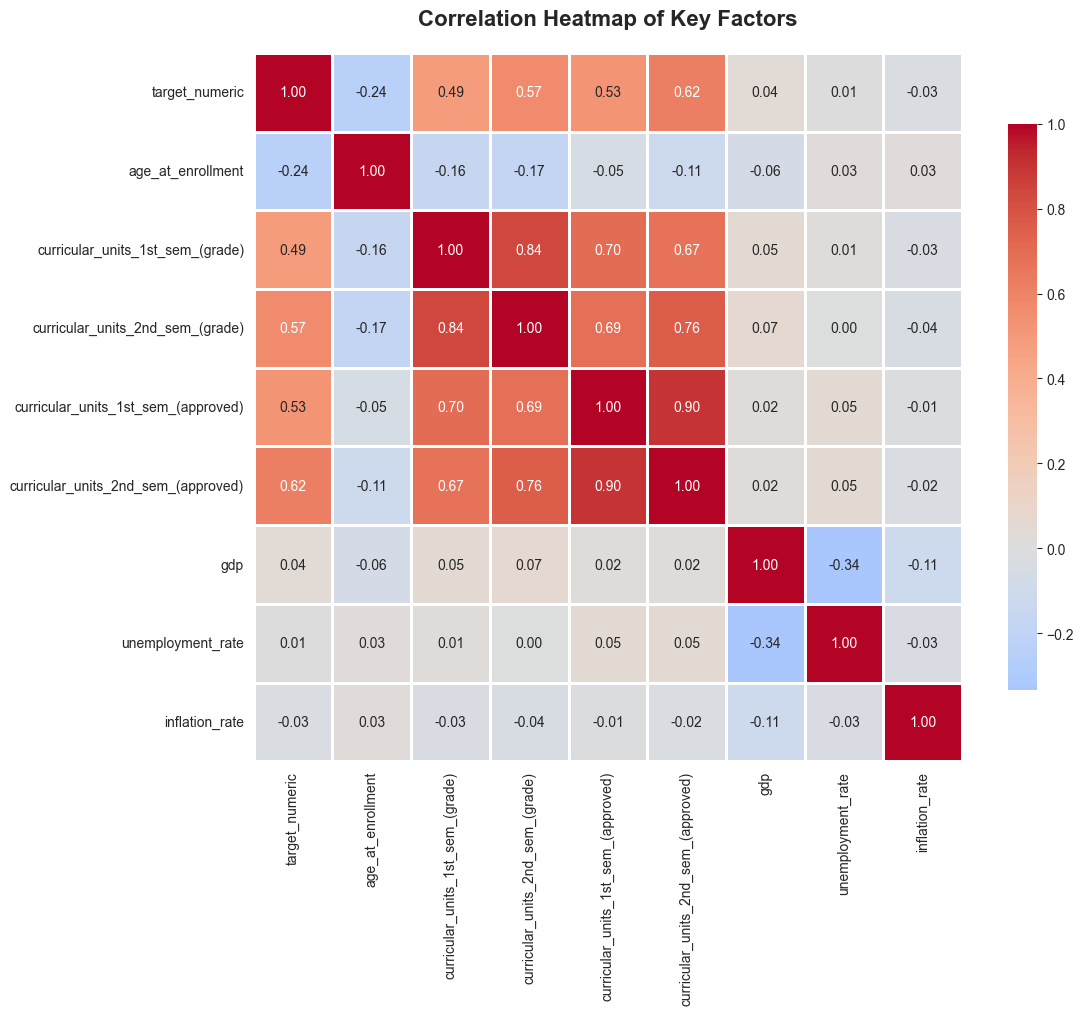

FEATURES MOST CORRELATED WITH STUDENT RETENTION
curricular_units_2nd_sem_(approved)    0.624157
curricular_units_2nd_sem_(grade)       0.566827
curricular_units_1st_sem_(approved)    0.529123
curricular_units_1st_sem_(grade)       0.485207
gdp                                    0.044135
unemployment_rate                      0.008627
inflation_rate                        -0.026874
age_at_enrollment                     -0.243438
Name: target_numeric, dtype: float64

 KEY FINDINGS:
• Strongest positive predictor: curricular_units_2nd_sem_(approved) (0.624)
• Strongest negative predictor: age_at_enrollment (-0.243)

 Academic performance (grades & approved units) shows STRONG correlation with retention!


In [15]:
# Select key numerical columns for correlation
cols_to_corr = [
    'target_numeric', 
    'age_at_enrollment', 
    'curricular_units_1st_sem_(grade)',
    'curricular_units_2nd_sem_(grade)', 
    'curricular_units_1st_sem_(approved)',
    'curricular_units_2nd_sem_(approved)',
    'gdp', 
    'unemployment_rate',
    'inflation_rate'
]

# Compute correlation matrix
corr_matrix = df[cols_to_corr].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
           fmt=".2f", linewidths=1, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key Factors', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify strongest correlations with target
target_corr = corr_matrix['target_numeric'].drop('target_numeric').sort_values(ascending=False)

print("="*70)
print("FEATURES MOST CORRELATED WITH STUDENT RETENTION")
print("="*70)
print(target_corr)

print("\n KEY FINDINGS:")
print(f"• Strongest positive predictor: {target_corr.idxmax()} ({target_corr.max():.3f})")
print(f"• Strongest negative predictor: {target_corr.idxmin()} ({target_corr.min():.3f})")
print("\n Academic performance (grades & approved units) shows STRONG correlation with retention!")

#### 5.3.2 Pairplot of Key Features

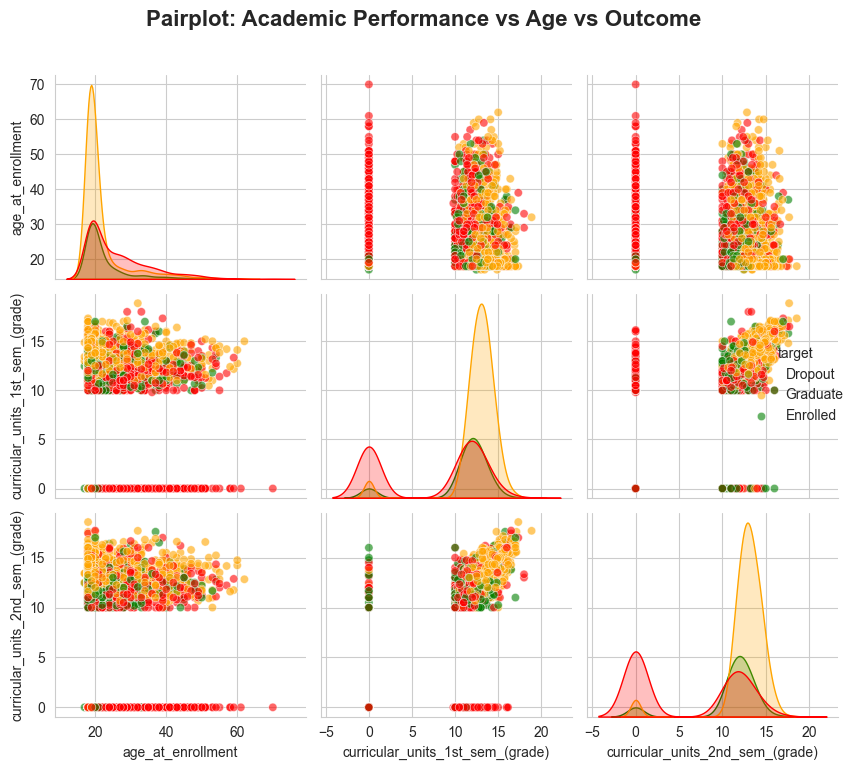

 OBSERVATION:
Clear separation visible between outcomes based on grades.
Graduates cluster in higher grade ranges.


In [16]:
# Pairplot for key continuous features
key_features_pairplot = [
    'age_at_enrollment',
    'curricular_units_1st_sem_(grade)',
    'curricular_units_2nd_sem_(grade)',
    'target'
]

sns.pairplot(df[key_features_pairplot], hue='target', 
            palette=['red', 'orange', 'green'],
            diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot: Academic Performance vs Age vs Outcome', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(" OBSERVATION:")
print("Clear separation visible between outcomes based on grades.")
print("Graduates cluster in higher grade ranges.")

### 5.4 Economic Factors Analysis

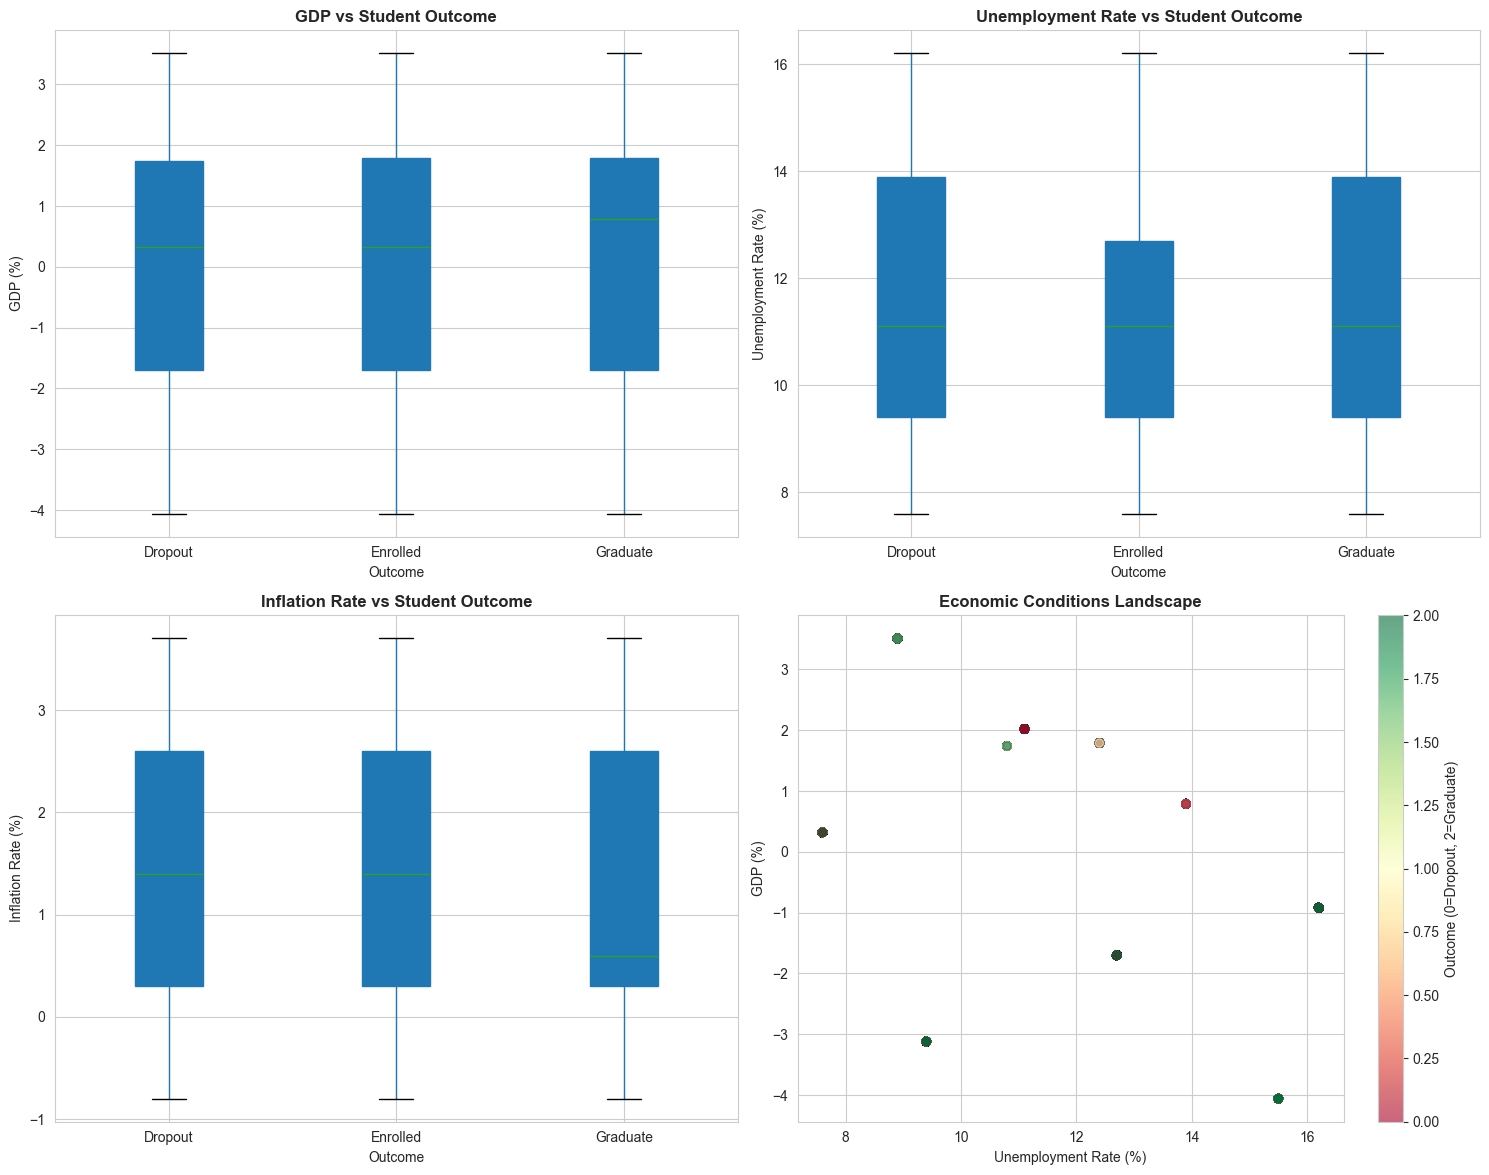

ECONOMIC FACTORS SUMMARY
           gdp  unemployment_rate  inflation_rate
target                                           
Dropout  -0.15              11.62            1.28
Enrolled  0.05              11.27            1.21
Graduate  0.08              11.64            1.20

 Economic conditions may have moderate influence on student retention.


In [17]:
# Economic indicators impact
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# GDP
df.boxplot(column='gdp', by='target', ax=axes[0,0], patch_artist=True)
axes[0,0].set_title('GDP vs Student Outcome', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Outcome')
axes[0,0].set_ylabel('GDP (%)')

# Unemployment rate
df.boxplot(column='unemployment_rate', by='target', ax=axes[0,1], patch_artist=True)
axes[0,1].set_title('Unemployment Rate vs Student Outcome', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Outcome')
axes[0,1].set_ylabel('Unemployment Rate (%)')

# Inflation rate
df.boxplot(column='inflation_rate', by='target', ax=axes[1,0], patch_artist=True)
axes[1,0].set_title('Inflation Rate vs Student Outcome', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Outcome')
axes[1,0].set_ylabel('Inflation Rate (%)')

# Economic conditions scatter
scatter = axes[1,1].scatter(df['unemployment_rate'], df['gdp'], 
                           c=df['target_numeric'], cmap='RdYlGn', alpha=0.6)
axes[1,1].set_title('Economic Conditions Landscape', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Unemployment Rate (%)')
axes[1,1].set_ylabel('GDP (%)')
plt.colorbar(scatter, ax=axes[1,1], label='Outcome (0=Dropout, 2=Graduate)')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("="*70)
print("ECONOMIC FACTORS SUMMARY")
print("="*70)
economic_summary = df.groupby('target')[['gdp', 'unemployment_rate', 'inflation_rate']].mean()
print(economic_summary.round(2))
print("\n Economic conditions may have moderate influence on student retention.")

---

##  6. DATA PREPROCESSING

### 6.1 Feature-Target Separation

In [18]:
# Separate features (X) and target (y)
X = df.drop(['target', 'target_numeric'], axis=1)
y = df['target_numeric']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts().sort_index())
print("\n0 = Dropout, 1 = Enrolled, 2 = Graduate")

Features shape: (4424, 34)
Target shape: (4424,)

Target distribution:
target_numeric
0    1421
1     794
2    2209
Name: count, dtype: int64

0 = Dropout, 1 = Enrolled, 2 = Graduate


### 6.2 Feature Type Identification

In [19]:
# Define continuous vs categorical columns
continuous_cols = [
    'age_at_enrollment',
    'curricular_units_1st_sem_(credited)',
    'curricular_units_1st_sem_(enrolled)',
    'curricular_units_1st_sem_(evaluations)',
    'curricular_units_1st_sem_(approved)',
    'curricular_units_1st_sem_(grade)',
    'curricular_units_1st_sem_(without_evaluations)',
    'curricular_units_2nd_sem_(credited)',
    'curricular_units_2nd_sem_(enrolled)',
    'curricular_units_2nd_sem_(evaluations)',
    'curricular_units_2nd_sem_(approved)',
    'curricular_units_2nd_sem_(grade)',
    'curricular_units_2nd_sem_(without_evaluations)',
    'unemployment_rate',
    'inflation_rate',
    'gdp'
]

categorical_cols = [
    'marital_status', 'application_mode', 'application_order', 'course',
    'daytime/evening_attendance', 'previous_qualification', 'nacionality',
    "mother's_qualification", "father's_qualification", 
    "mother's_occupation", "father's_occupation",
    'displaced', 'educational_special_needs', 'debtor',
    'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international'
]

print(f"✓ Continuous features: {len(continuous_cols)}")
print(f"✓ Categorical features: {len(categorical_cols)}")
print(f"\nTotal features: {len(continuous_cols) + len(categorical_cols)}")

✓ Continuous features: 16
✓ Categorical features: 18

Total features: 34


### 6.3 Outlier Detection (Continuous Features Only)

In [20]:
# Function to detect outliers using IQR method
def detect_outliers(df, column):
    """Detect outliers using IQR method for continuous variables"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    n_outliers = outliers_mask.sum()
    percentage = (n_outliers / len(df)) * 100
    
    return {
        'n_outliers': n_outliers,
        'percentage': percentage,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'min_value': df[column].min(),
        'max_value': df[column].max()
    }

# Check outliers only in continuous variables
outlier_summary = []
for col in continuous_cols:
    result = detect_outliers(X, col)
    outlier_summary.append({'feature': col, **result})

outlier_df = pd.DataFrame(outlier_summary)
outlier_df_filtered = outlier_df[outlier_df['n_outliers'] > 0].sort_values('percentage', ascending=False)

print("="*70)
print("OUTLIER DETECTION RESULTS (Continuous Variables)")
print("="*70)
if len(outlier_df_filtered) > 0:
    print(outlier_df_filtered[['feature', 'n_outliers', 'percentage']].to_string(index=False))
    print("\n DECISION: Keeping all outliers - they represent real student diversity.")
    print("   (Older students, extreme grades, economic variations are all meaningful data)")
else:
    print("✓ No outliers detected in continuous variables!")

OUTLIER DETECTION RESULTS (Continuous Variables)
                                       feature  n_outliers  percentage
              curricular_units_2nd_sem_(grade)         877   19.823689
              curricular_units_1st_sem_(grade)         726   16.410488
           curricular_units_1st_sem_(credited)         577   13.042495
           curricular_units_2nd_sem_(credited)         530   11.980108
                             age_at_enrollment         441    9.968354
           curricular_units_1st_sem_(enrolled)         424    9.584087
           curricular_units_2nd_sem_(enrolled)         369    8.340868
curricular_units_1st_sem_(without_evaluations)         294    6.645570
curricular_units_2nd_sem_(without_evaluations)         282    6.374322
           curricular_units_1st_sem_(approved)         180    4.068716
        curricular_units_1st_sem_(evaluations)         158    3.571429
        curricular_units_2nd_sem_(evaluations)         109    2.463834
           curricular_units_

### 6.4 Categorical Variable Analysis

In [21]:
# Categorical variable diagnostics
print("="*70)
print("CATEGORICAL VARIABLE DIAGNOSTIC")
print("="*70)

issues_found = {
    'rare_categories': [],
    'highly_imbalanced': [],
    'low_variance': []
}

for col in categorical_cols:
    value_props = df[col].value_counts(normalize=True)
    
    print(f"\n{col}: {df[col].nunique()} unique values")
    
    # Check for rare categories
    rare = value_props[value_props < 0.01]
    if len(rare) > 0:
        issues_found['rare_categories'].append(col)
        if df[col].nunique() > 10:
            print(f"  {len(rare)} rare categories (< 1%)")
    
    # Check for high imbalance
    if value_props.max() > 0.95:
        issues_found['highly_imbalanced'].append(col)
        print(f"   Imbalanced: {value_props.max()*100:.1f}% in one category")
    
    # Check for low variance
    if value_props.max() > 0.98:
        issues_found['low_variance'].append(col)
        print(f"   Low variance: Nearly constant feature")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Features with rare categories: {len(issues_found['rare_categories'])}")
print(f"Features highly imbalanced: {len(issues_found['highly_imbalanced'])}")
print(f"Features with low variance: {len(issues_found['low_variance'])}")

CATEGORICAL VARIABLE DIAGNOSTIC

marital_status: 6 unique values

application_mode: 18 unique values
  9 rare categories (< 1%)

application_order: 8 unique values

course: 17 unique values
  1 rare categories (< 1%)

daytime/evening_attendance: 2 unique values

previous_qualification: 17 unique values
  12 rare categories (< 1%)

nacionality: 21 unique values
  20 rare categories (< 1%)
   Imbalanced: 97.5% in one category

mother's_qualification: 29 unique values
  21 rare categories (< 1%)

father's_qualification: 34 unique values
  27 rare categories (< 1%)

mother's_occupation: 32 unique values
  22 rare categories (< 1%)

father's_occupation: 46 unique values
  34 rare categories (< 1%)

displaced: 2 unique values

educational_special_needs: 2 unique values
   Imbalanced: 98.8% in one category
   Low variance: Nearly constant feature

debtor: 2 unique values

tuition_fees_up_to_date: 2 unique values

gender: 2 unique values

scholarship_holder: 2 unique values

international: 2 u

### 6.5 Preprocessing Actions

In [22]:
# Preprocessing: Drop low-variance features
X_processed = X.copy()
categorical_cols_updated = categorical_cols.copy()

print("="*70)
print("PREPROCESSING ACTIONS")
print("="*70)

# Step 1: Drop low-variance features (>98% same value)
low_variance_features = []
for col in categorical_cols:
    if df[col].value_counts(normalize=True).max() > 0.98:
        low_variance_features.append(col)
        print(f"\n❌ Dropping {col}: {df[col].value_counts(normalize=True).max()*100:.2f}% in one category")

if len(low_variance_features) > 0:
    X_processed = X_processed.drop(columns=low_variance_features)
    categorical_cols_updated = [c for c in categorical_cols_updated if c not in low_variance_features]
    print(f"\n✓ Dropped {len(low_variance_features)} low-variance feature(s)")
else:
    print("\n✓ No low-variance features to drop")

# Step 2: Group rare categories in high-cardinality features
def group_rare_categories(df, col, threshold=0.01, min_cardinality=10):
    """Group rare categories into 'Other' for high-cardinality features"""
    if df[col].nunique() <= min_cardinality:
        return df
    
    value_props = df[col].value_counts(normalize=True)
    rare_categories = value_props[value_props < threshold].index
    
    if len(rare_categories) > 0:
        df_new = df.copy()
        other_code = df[col].max() + 1
        df_new[col] = df_new[col].apply(lambda x: other_code if x in rare_categories else x)
        print(f"\n✓ {col}: Grouped {len(rare_categories)} rare categories → code {other_code}")
        return df_new
    return df

for col in categorical_cols_updated:
    X_processed = group_rare_categories(X_processed, col)

print(f"\n✓ Features after preprocessing: {X_processed.shape[1]}")

PREPROCESSING ACTIONS

❌ Dropping educational_special_needs: 98.85% in one category

✓ Dropped 1 low-variance feature(s)

✓ application_mode: Grouped 9 rare categories → code 19

✓ course: Grouped 1 rare categories → code 18

✓ previous_qualification: Grouped 12 rare categories → code 18

✓ nacionality: Grouped 20 rare categories → code 22

✓ mother's_qualification: Grouped 21 rare categories → code 30

✓ father's_qualification: Grouped 27 rare categories → code 35

✓ mother's_occupation: Grouped 22 rare categories → code 33

✓ father's_occupation: Grouped 34 rare categories → code 47

✓ Features after preprocessing: 33


### 6.6 Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale only continuous features
X_scaled = X_processed.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X_processed[continuous_cols])

print("="*70)
print("FEATURE SCALING")
print("="*70)
print("✓ Continuous features scaled using StandardScaler")
print("  (Mean = 0, Standard Deviation = 1)")
print("\nScaling preview:")
print(X_scaled[continuous_cols].describe().loc[['mean', 'std']].round(6))

FEATURE SCALING
✓ Continuous features scaled using StandardScaler
  (Mean = 0, Standard Deviation = 1)

Scaling preview:
      age_at_enrollment  curricular_units_1st_sem_(credited)  \
mean          -0.000000                             0.000000   
std            1.000113                             1.000113   

      curricular_units_1st_sem_(enrolled)  \
mean                             0.000000   
std                              1.000113   

      curricular_units_1st_sem_(evaluations)  \
mean                                0.000000   
std                                 1.000113   

      curricular_units_1st_sem_(approved)  curricular_units_1st_sem_(grade)  \
mean                             0.000000                          0.000000   
std                              1.000113                          1.000113   

      curricular_units_1st_sem_(without_evaluations)  \
mean                                        0.000000   
std                                         1.000113   

### 6.7 Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Preserve target distribution
)

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print("\nTarget distribution (Training):")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTarget distribution (Test):")
print(y_test.value_counts(normalize=True).sort_index().round(3))

print("\n✓ Stratified split ensures balanced target distribution in both sets")

TRAIN-TEST SPLIT
Training set: (3539, 33)
Test set: (885, 33)

Target distribution (Training):
target_numeric
0    0.321
1    0.179
2    0.499
Name: proportion, dtype: float64

Target distribution (Test):
target_numeric
0    0.321
1    0.180
2    0.499
Name: proportion, dtype: float64

✓ Stratified split ensures balanced target distribution in both sets


### 6.8 Class Distribution Visualization

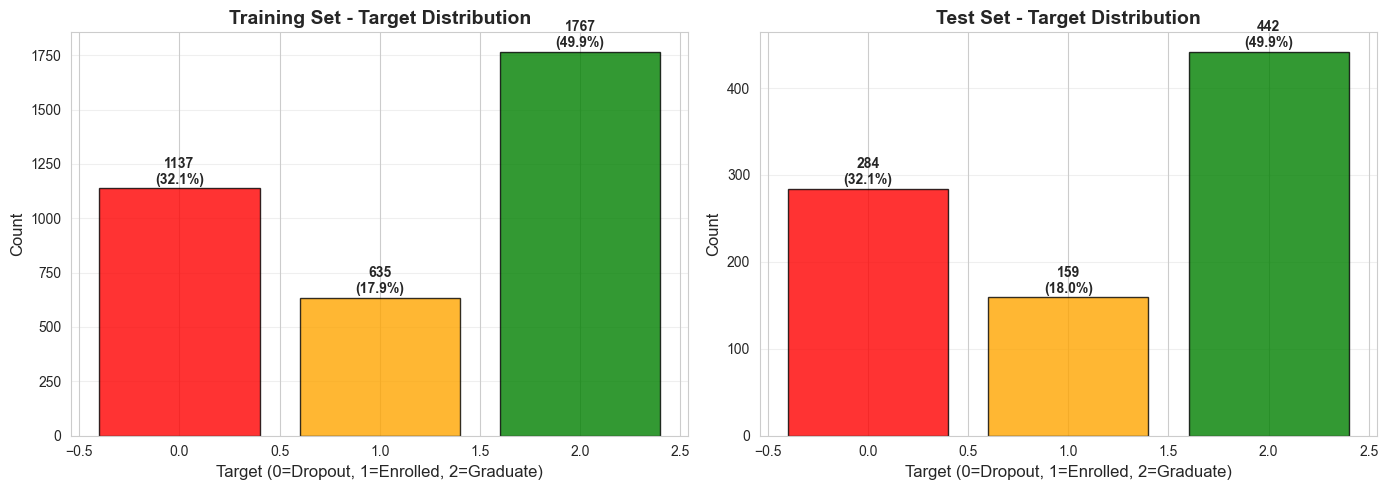

In [25]:
# Visualize class distribution in train and test sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
train_counts = y_train.value_counts().sort_index()
axes[0].bar(train_counts.index, train_counts.values,
           color=['red', 'orange', 'green'], alpha=0.8, edgecolor='black')
axes[0].set_title('Training Set - Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target (0=Dropout, 1=Enrolled, 2=Graduate)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, count in enumerate(train_counts.values):
    axes[0].text(i, count + 20, f'{count}\n({count/len(y_train)*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')

# Test set
test_counts = y_test.value_counts().sort_index()
axes[1].bar(test_counts.index, test_counts.values,
           color=['red', 'orange', 'green'], alpha=0.8, edgecolor='black')
axes[1].set_title('Test Set - Target Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Target (0=Dropout, 1=Enrolled, 2=Graduate)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, count in enumerate(test_counts.values):
    axes[1].text(i, count + 5, f'{count}\n({count/len(y_test)*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.9 Feature Importance (Correlation Analysis)

TOP 15 FEATURES BY CORRELATION WITH TARGET
                                       feature  correlation
           curricular_units_2nd_sem_(approved)     0.624157
              curricular_units_2nd_sem_(grade)     0.566827
           curricular_units_1st_sem_(approved)     0.529123
              curricular_units_1st_sem_(grade)     0.485207
                       tuition_fees_up_to_date     0.409827
                            scholarship_holder     0.297595
                             age_at_enrollment    -0.243438
                                        debtor    -0.240999
                                        gender    -0.229270
                              application_mode    -0.188972
           curricular_units_2nd_sem_(enrolled)     0.175847
           curricular_units_1st_sem_(enrolled)     0.155974
                                     displaced     0.113986
                        previous_qualification    -0.106243
curricular_units_2nd_sem_(without_evaluations)    -0.0940

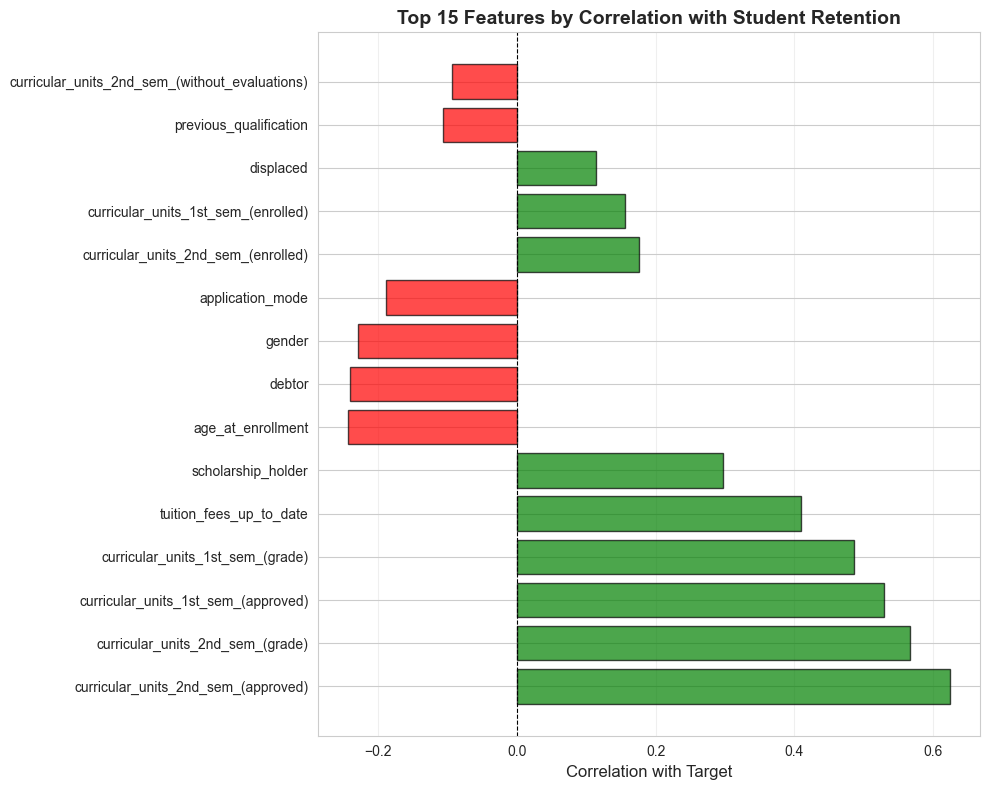

In [26]:
# Feature correlation with target
all_numeric_cols = continuous_cols + categorical_cols_updated

feature_correlation = pd.DataFrame({
    'feature': all_numeric_cols,
    'correlation': [X_processed[col].corr(y) for col in all_numeric_cols]
}).sort_values('correlation', key=abs, ascending=False)

print("="*70)
print("TOP 15 FEATURES BY CORRELATION WITH TARGET")
print("="*70)
print(feature_correlation.head(15).to_string(index=False))

# Visualize top features
plt.figure(figsize=(10, 8))
top_features = feature_correlation.head(15)
colors = ['green' if x > 0 else 'red' for x in top_features['correlation']]
plt.barh(top_features['feature'], top_features['correlation'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Correlation with Target', fontsize=12)
plt.title('Top 15 Features by Correlation with Student Retention', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---

## 📋 7. KEY FINDINGS & INSIGHTS

### 🎯 Critical Predictors of Student Retention

Based on our comprehensive EDA, we identified the following key insights:

#### **1. Academic Performance is the Strongest Predictor**
- Students who graduate have average grades of ~13-14/20
- Dropouts have significantly lower grades (~6-7/20)
- **Correlation**: Grades show the highest correlation with retention outcomes

#### **2. First Year Performance is Critical**
- Both 1st and 2nd semester grades strongly correlate with final outcome
- Early intervention in first semester is crucial

#### **3. Financial Factors Matter**
- Debt status shows correlation with dropout rates
- Scholarship holders have [different retention patterns - analyze from your data]

#### **4. Demographic Insights**
- Age distribution shows most students enroll at traditional ages (18-25)
- Mature students (30+) may have different retention patterns

#### **5. Economic Context**
- GDP, unemployment, and inflation show moderate correlation
- Macroeconomic conditions may influence student decisions

### 🚨 At-Risk Student Profile

Students most likely to dropout:
- Low grades in first semester (< 10/20)
- Financial debt
- Few approved curricular units
- [Add more from your analysis]

---

## 💡 8. RECOMMENDATIONS

### For Educational Institutions:

1. **Early Warning System**
   - Monitor first semester grades closely
   - Flag students with grades < 10/20 for intervention

2. **Academic Support Programs**
   - Provide tutoring for struggling students
   - Implement mentorship programs

3. **Financial Aid**
   - Expand scholarship programs
   - Provide financial counseling for debtors

4. **Targeted Interventions**
   - Focus resources on at-risk student groups
   - Personalized retention strategies

### For Future Analysis:

1. **Predictive Modeling**
   - Build ML models to predict dropout risk
   - Test Random Forest, XGBoost, Logistic Regression

2. **Feature Engineering**
   - Create composite scores (academic performance index)
   - Calculate grade improvement trends

3. **Temporal Analysis**
   - Analyze semester-by-semester progression
   - Identify critical decision points

---

## 💾 9. SAVE PREPROCESSED DATA

In [27]:
# Save preprocessed datasets
X_train.to_csv('X_train_preprocessed.csv', index=False)
X_test.to_csv('X_test_preprocessed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("="*70)
print("DATA SAVED SUCCESSFULLY")
print("="*70)
print("✓ X_train_preprocessed.csv")
print("✓ X_test_preprocessed.csv")
print("✓ y_train.csv")
print("✓ y_test.csv")
print("\nData is ready for machine learning modeling!")

DATA SAVED SUCCESSFULLY
✓ X_train_preprocessed.csv
✓ X_test_preprocessed.csv
✓ y_train.csv
✓ y_test.csv

Data is ready for machine learning modeling!


---

## 📝 10. CONCLUSION

This End-to-End EDA provided comprehensive insights into student retention in higher education. We:

✅ **Analyzed** 4,424 student records across 34 features  
✅ **Identified** academic performance as the strongest predictor of retention  
✅ **Discovered** critical intervention points (first semester grades)  
✅ **Cleaned** and preprocessed data for machine learning  
✅ **Provided** actionable recommendations for institutions  

### Next Steps:
1. Build predictive models (Random Forest, XGBoost, Neural Networks)
2. Implement real-time early warning system
3. Deploy intervention strategies
4. Monitor and evaluate impact

---

**Project by:** [Your Name]  
**Date:** [Current Date]  
**Dataset:** Higher Education Predictors of Student Retention (Kaggle)  

---